In [ ]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/data_files/customer_churn_dataset.csv'
df = pd.read_csv(file_path, keep_default_na=False)

print(df)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
       customer_id  tenure  monthly_charges  total_charges        contract  \
0                1      52            54.20        2818.40  Month-to-month   
1                2      15            35.28         529.20  Month-to-month   
2                3      72            78.24        5633.28  Month-to-month   
3                4      61            80.24        4894.64        One year   
4                5      21            39.38         826.98  Month-to-month   
...            ...     ...              ...            ...             ...   
19995        19996      36            69.51        2502.36        Two year   
19996        19997      10            59.88         598.80  Month-to-month   
19997        19998       6            42.96         257.76  Month-to-month   
19998        19999       7           102.85         719.95  Month-to-month   
19999        

In [ ]:
df["payment_method"].unique()

array(['Credit', 'Debit', 'Cash', 'UPI'], dtype=object)

In [ ]:
df["churn"]=df["churn"].map({"Yes":1, "No":0})
df["tech_support"]=df["tech_support"].map({"Yes":1, "No":0})
df["online_security"]=df["online_security"].map({"Yes":1, "No":0})
print(df)

       customer_id  tenure  monthly_charges  total_charges        contract  \
0                1      52            54.20        2818.40  Month-to-month   
1                2      15            35.28         529.20  Month-to-month   
2                3      72            78.24        5633.28  Month-to-month   
3                4      61            80.24        4894.64        One year   
4                5      21            39.38         826.98  Month-to-month   
...            ...     ...              ...            ...             ...   
19995        19996      36            69.51        2502.36        Two year   
19996        19997      10            59.88         598.80  Month-to-month   
19997        19998       6            42.96         257.76  Month-to-month   
19998        19999       7           102.85         719.95  Month-to-month   
19999        20000      31            44.84        1390.04        Two year   

      payment_method internet_service  tech_support  online_sec

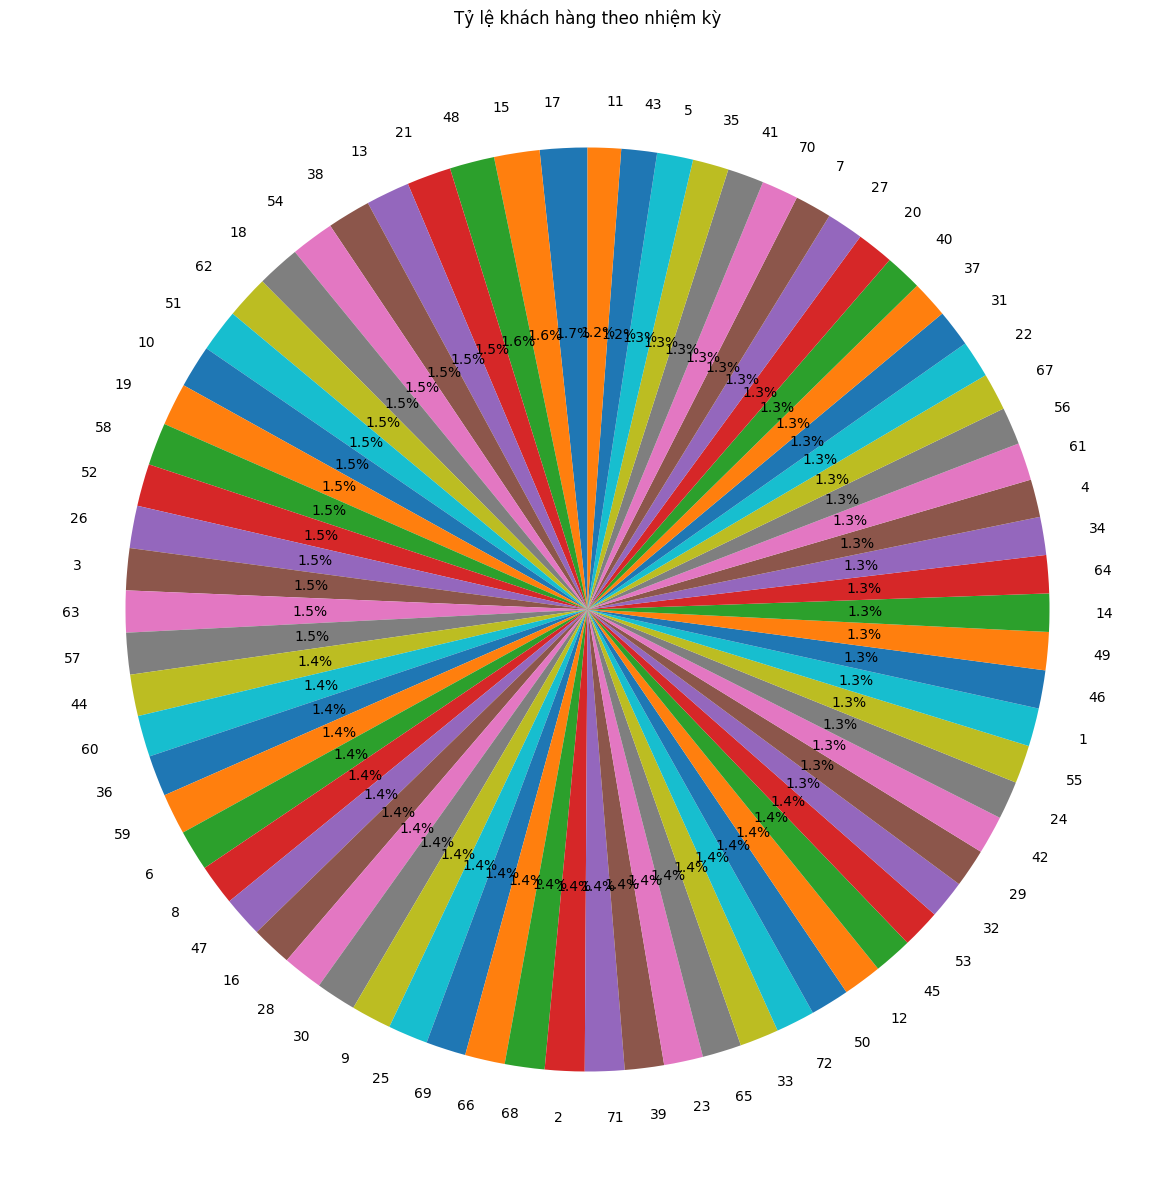

In [ ]:

counts = df["tenure"].value_counts()

plt.figure(figsize=(15, 15))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Tỷ lệ khách hàng theo nhiệm kỳ")
plt.show()

In [ ]:
print(df["tenure"].mean())
print(df["tenure"].median())
print(df["tenure"].mode())

36.46745
36.0
0    17
Name: tenure, dtype: int64


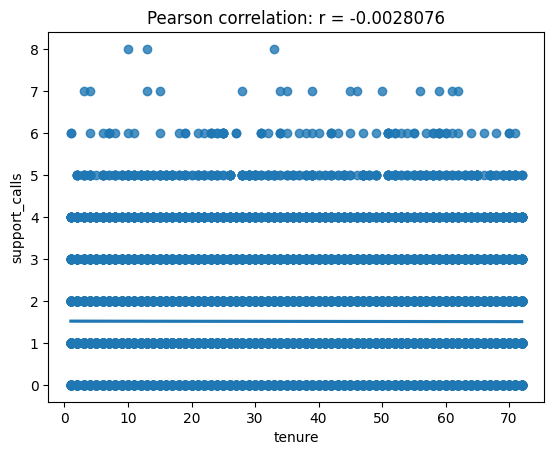

In [ ]:
#test

r = df["tenure"].corr(df["support_calls"])

sns.regplot(
    data=df,
    x="tenure",
    y="support_calls"
)

plt.title(f"Pearson correlation: r = {r:.7f}")
plt.show()

In [ ]:
print(df["tenure"].min())
print(df["tenure"].max())

1
72


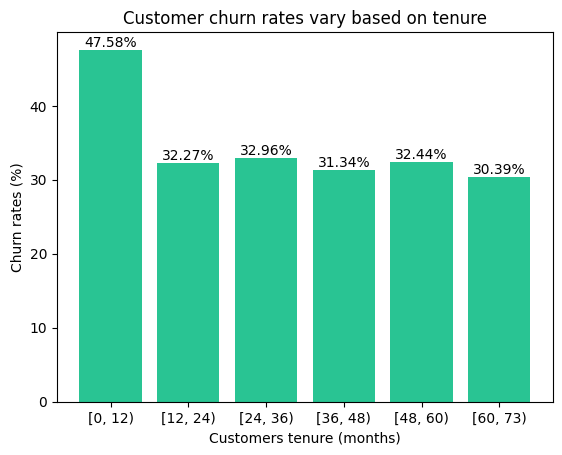

In [ ]:
bins=[0,12,24,36,48,60,73]
df["tenure_group"] = pd.cut(df["tenure"], bins=bins, right=False)

#plt.figure(figsize=(8, 6))
churn_rate = (df.groupby("tenure_group", observed=True)["churn"].mean() * 100)
plt.bar(churn_rate.index.astype(str), churn_rate.values, color="#29c493")
for i, value in enumerate(churn_rate.values):
    plt.text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )

plt.title('Customer churn rates vary based on tenure')
plt.xlabel('Customers tenure (months)')
plt.ylabel('Churn rates (%)')

plt.show()

In [ ]:
table = pd.crosstab(df["tenure_group"], df["churn"])
print(table)
chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

churn            0     1
tenure_group            
[0, 12)       1570  1425
[12, 24)      2355  1122
[24, 36)      2180  1072
[36, 48)      2241  1023
[48, 60)      2314  1111
[60, 73)      2497  1090
Chi-square statistic: 285.88465513860297
p-value: 1.0829049284605936e-59
Degrees of freedom: 5


In [ ]:
print(df["monthly_charges"].min())
print(df["monthly_charges"].max())

20.0
120.0


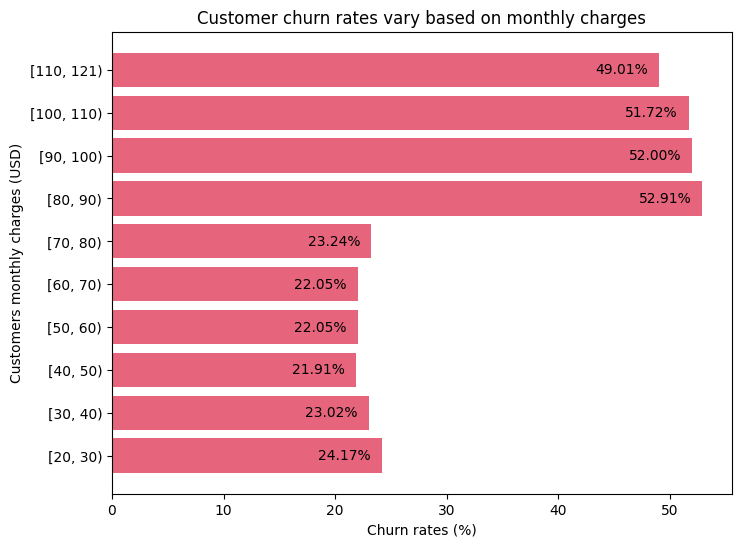

In [ ]:
bins=[20,30,40,50,60,70,80,90,100,110,121]
df["monthly_charges_group"] = pd.cut(df["monthly_charges"], bins=bins, right=False)
churn_rate = (df.groupby("monthly_charges_group", observed=True)["churn"].mean() * 100)

plt.figure(figsize=(8, 6))
plt.barh(churn_rate.index.astype(str), churn_rate.values, color="#e6657d")
for i, value in enumerate(churn_rate.values):
    plt.text(
        value - 1,
        i,
        f"{value:.2f}%",
        ha="right",
        va="center"
    )

plt.title('Customer churn rates vary based on monthly charges')
plt.ylabel('Customers monthly charges (USD)')
plt.xlabel('Churn rates (%)')

plt.show()

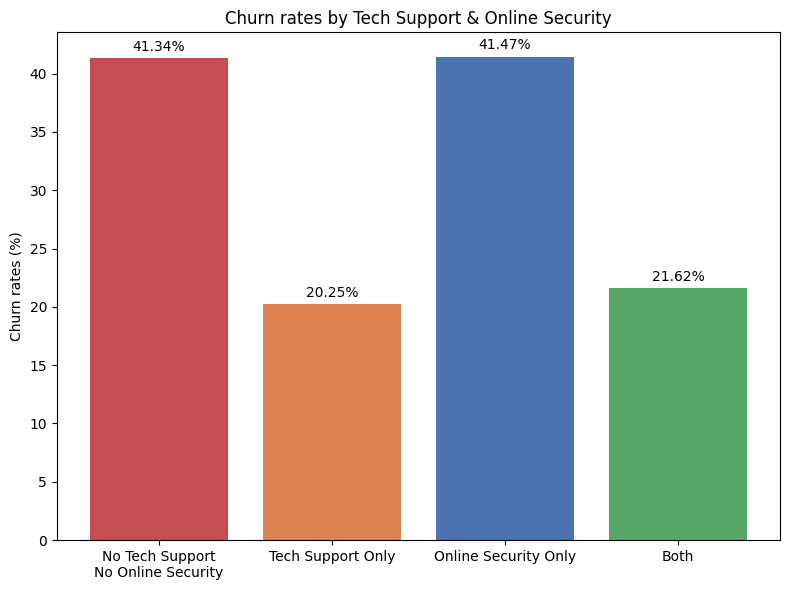

In [ ]:
# Do customers with Tech Support or Online Security have lower churn rates?
df["churn_group"] = np.select(
    [
    (df["tech_support"] == 0) & (df["online_security"] == 0),
    (df["tech_support"] == 1) & (df["online_security"] == 0),
    (df["tech_support"] == 0) & (df["online_security"] == 1),
    (df["tech_support"] == 1) & (df["online_security"] == 1)
    ],
    ['No Tech Support\nNo Online Security',
    'Tech Support Only',
    'Online Security Only',
    'Both'],
    default='None'
)

churn_rates_by_group = df.groupby("churn_group")["churn"].mean() * 100

order = [
    'No Tech Support\nNo Online Security',
    'Tech Support Only',
    'Online Security Only',
    'Both']
churn_rates_by_group = churn_rates_by_group.reindex(order)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(churn_rates_by_group.index, churn_rates_by_group.values,
              color=['#C44E52', '#DD8452', '#4C72B0', '#55A868'])
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_ylabel('Churn rates (%)')
#ax.set_xlabel('Tech Support (Yes/No) & Online Security (Yes/No)')
ax.set_title('Churn rates by Tech Support & Online Security')

plt.tight_layout()
plt.show()

In [ ]:
df["support_calls"].unique()

array([1, 2, 0, 4, 3, 6, 5, 7, 8])

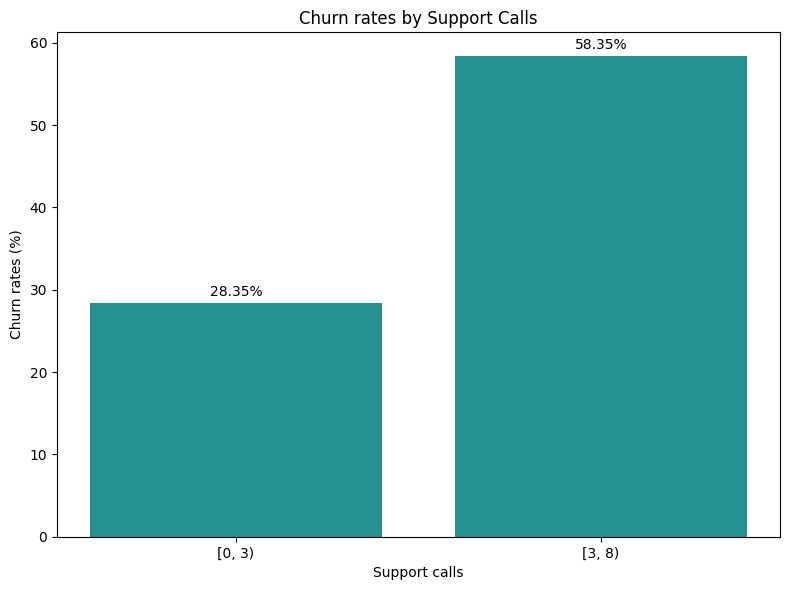

In [ ]:
bins = [0, 3, 8]
df["support_calls_group"] = pd.cut(df["support_calls"], bins = bins, right=False)
churn_rates_by_supportcalls = df.groupby("support_calls_group", observed=True)["churn"].mean() * 100

fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(churn_rates_by_supportcalls.index.astype(str), churn_rates_by_supportcalls.values, color="#269191")
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_ylabel('Churn rates (%)')
ax.set_xlabel('Support calls')
ax.set_title('Churn rates by Support Calls')

plt.tight_layout()
plt.show()

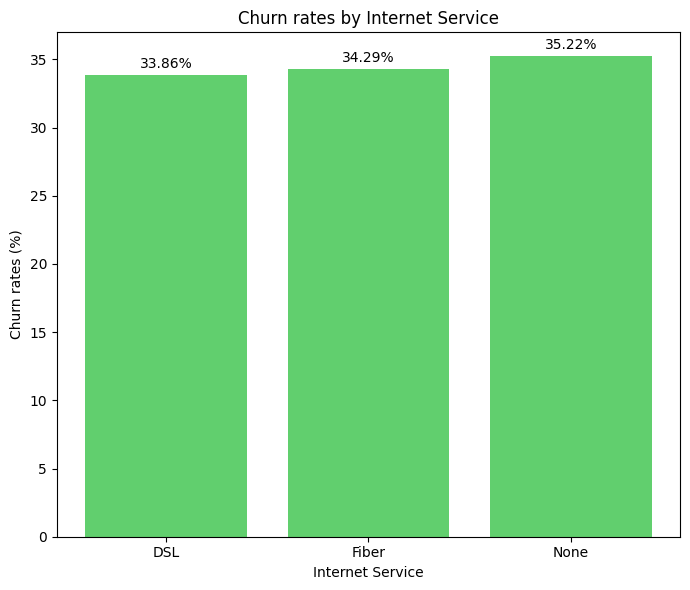

In [ ]:
churn_rates_by_internetservice = df.groupby("internet_service")["churn"].mean() * 100

fig, ax = plt.subplots(figsize=(7,6))
bars = ax.bar(churn_rates_by_internetservice.index, churn_rates_by_internetservice.values, color="#61cf6e")
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_ylabel('Churn rates (%)')
ax.set_xlabel('Internet Service')
ax.set_title('Churn rates by Internet Service')

plt.tight_layout()
plt.show()

In [ ]:
table = pd.crosstab(df["internet_service"], df["churn"])
print(table)

churn                0     1
internet_service            
DSL               5240  2683
Fiber             6613  3451
None              1304   709


In [ ]:
chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 1.365794473959248
p-value: 0.5051513270958423
Degrees of freedom: 2


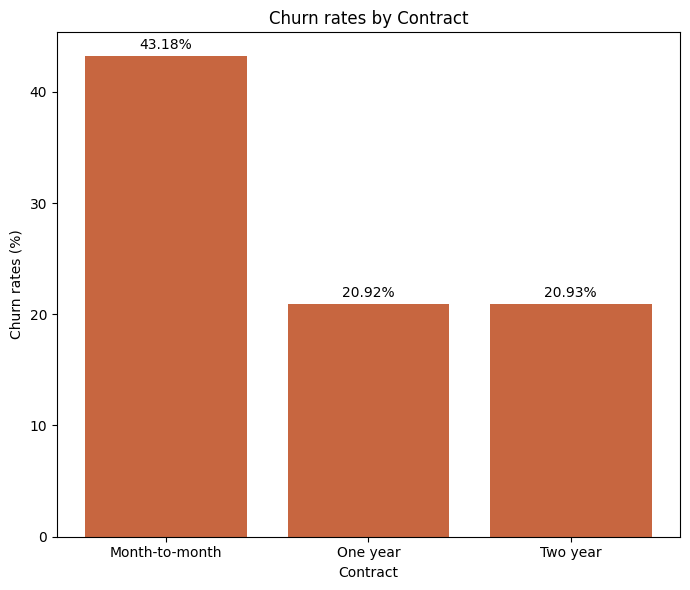

In [ ]:
churn_rates_by_contract = df.groupby("contract")["churn"].mean() * 100

fig, ax = plt.subplots(figsize=(7,6))
bars = ax.bar(churn_rates_by_contract.index, churn_rates_by_contract.values, color="#c76640")
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_ylabel('Churn rates (%)')
ax.set_xlabel('Contract')
ax.set_title('Churn rates by Contract')

plt.tight_layout()
plt.show()

In [ ]:
table = pd.crosstab(df["contract"], df["churn"])
print(table)

chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

churn              0     1
contract                  
Month-to-month  6785  5157
One year        3946  1044
Two year        2426   642
Chi-square statistic: 1059.2474824022893
p-value: 9.712515197996976e-231
Degrees of freedom: 2


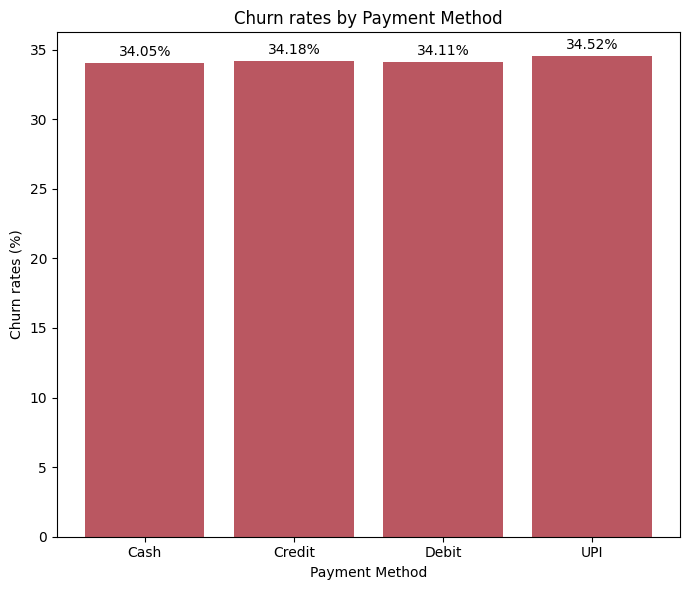

In [ ]:
churn_rates_by_paymentmethod = df.groupby("payment_method")["churn"].mean() * 100

fig, ax = plt.subplots(figsize=(7,6))
bars = ax.bar(churn_rates_by_paymentmethod.index, churn_rates_by_paymentmethod.values, color="#ba5761")
ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.set_ylabel('Churn rates (%)')
ax.set_xlabel('Payment Method')
ax.set_title('Churn rates by Payment Method')

plt.tight_layout()
plt.show()

In [ ]:
table = pd.crosstab(df["payment_method"], df["churn"])
print(table)

chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

churn              0     1
payment_method            
Cash            3294  1701
Credit          3308  1718
Debit           3311  1714
UPI             3244  1710
Chi-square statistic: 0.28623373209724723
p-value: 0.9625964044826463
Degrees of freedom: 3


In [ ]:
cols = ['tenure_group', 'monthly_charges_group', 'tech_support', 'online_security', 'contract', 'support_calls_group']

df['combine'] = df[cols].astype(str).agg(' | '.join, axis=1)

combo_summary = df.groupby('combine')['churn'].agg(['mean', 'count'])
combo_summary['mean'] = combo_summary['mean'] * 100
combo_summary.columns = ['churn_rate', 'n_customers']

combo_summary_filtered = combo_summary[combo_summary['n_customers'] >= 30]
combo_summary_filtered = combo_summary_filtered.sort_values('churn_rate', ascending=False)

print(f"Số tổ hợp đủ điều kiện (n≥30): {len(combo_summary_filtered)} / {len(combo_summary)} tổng tổ hợp")

Số tổ hợp đủ điều kiện (n≥30): 189 / 1403 tổng tổ hợp


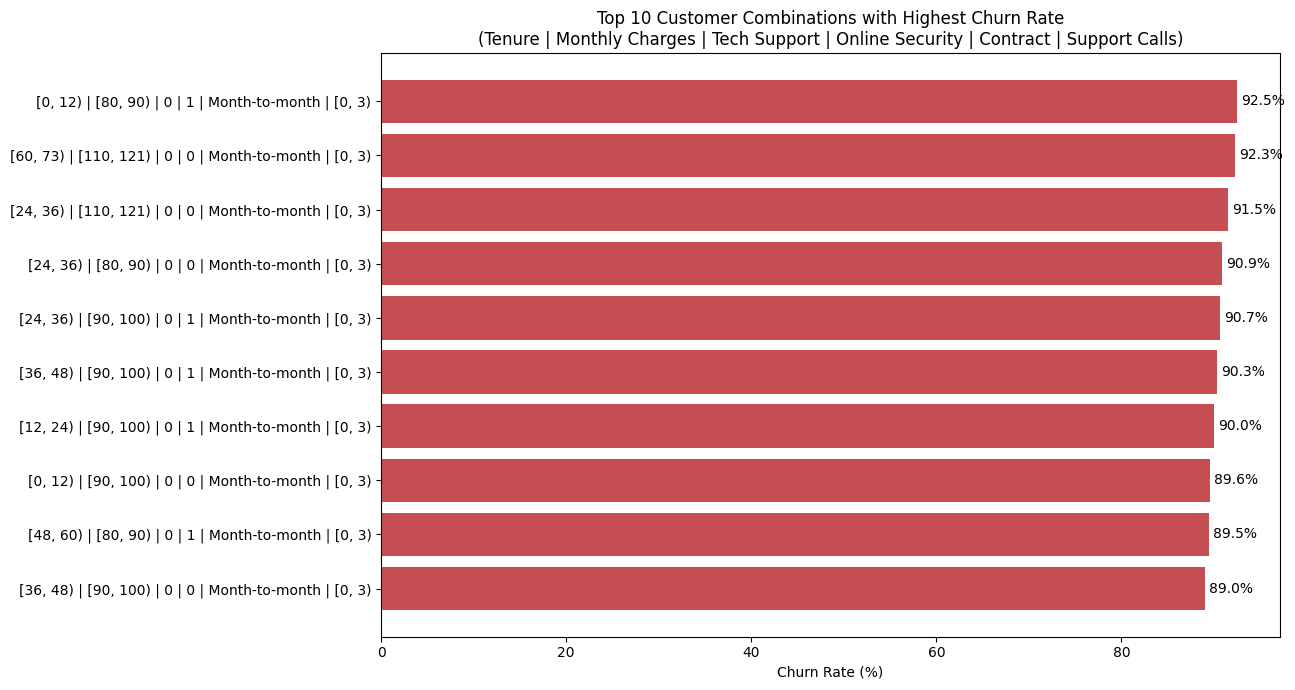

In [ ]:
top_n = combo_summary_filtered.head(10)

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top_n.index[::-1], top_n['churn_rate'][::-1], color='#C44E52')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Top 10 Customer Combinations with Highest Churn Rate\n(Tenure | Monthly Charges | Tech Support | Online Security | Contract | Support Calls)')

plt.tight_layout()
plt.show()

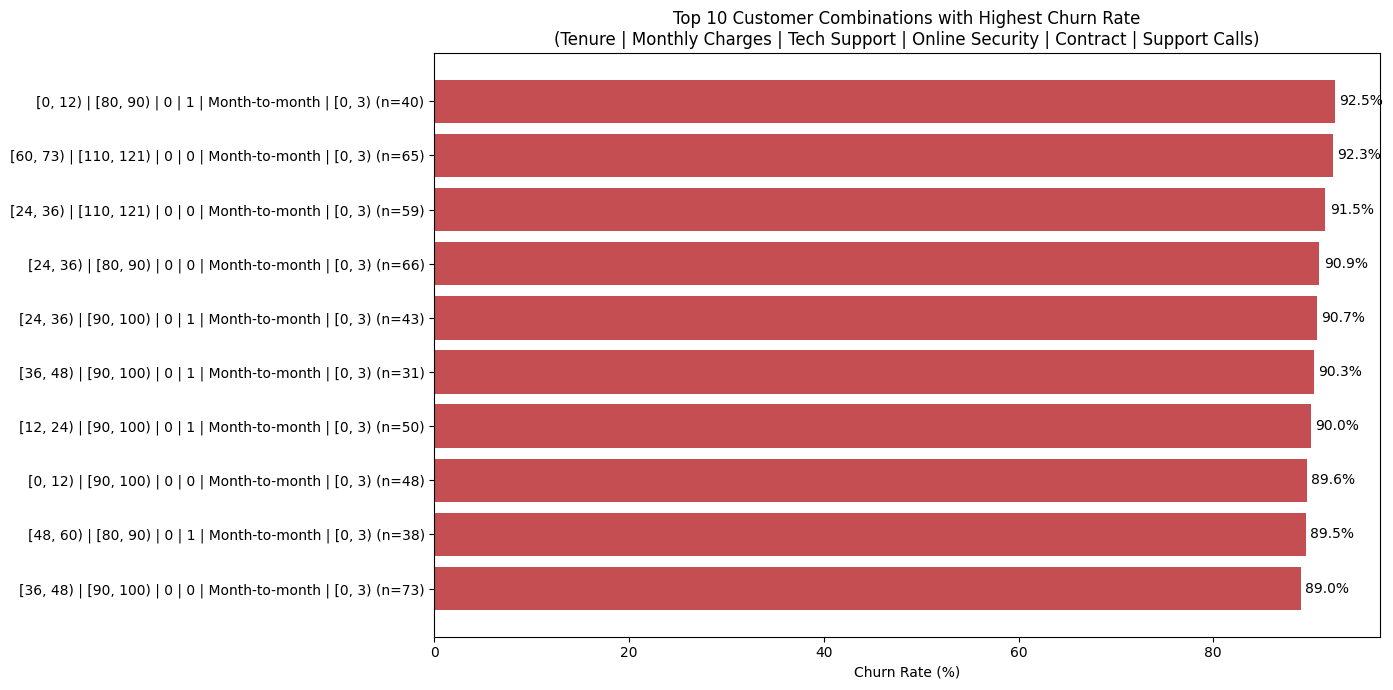

In [ ]:
top_n = combo_summary_filtered.head(10).copy()
top_n['label'] = top_n.apply(lambda r: f"{r.name} (n={int(r['n_customers'])})", axis=1)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(top_n['label'][::-1], top_n['churn_rate'][::-1], color='#C44E52')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlabel('Churn Rate (%)')
ax.set_title('Top 10 Customer Combinations with Highest Churn Rate\n(Tenure | Monthly Charges | Tech Support | Online Security | Contract | Support Calls)')
plt.tight_layout()
plt.show()